## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [32]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230

In [ ]:
url = f"https://api.open-meteo.com/v1/forecast?latitude=43.2540&longitude=-2.9230&hourly=temperature_2m"  # Aquí vienen el resto de los parámetros
response = requests.get(url)
response = requests.get(url)
data = response.json()
temps = data["hourly"]["temperature_2m"] # Creamos una lista de temperaturas a partir de los datos obtenidos
lista_de_horas = data["hourly"]["time"] # Creamos una lista de horas a partir de los datos obtenidos
temps_df = pd.DataFrame({"hora": lista_de_horas, "temperatura": temps}) # Creamos un DataFrame con las horas y las temperaturas
temps_df.head() # Mostramos las primeras filas del DataFrame para verificar que se ha creado correctamente

,hora,temperatura
0,2026-03-23T00:00,12.3
1,2026-03-23T01:00,12.1
2,2026-03-23T02:00,11.8
3,2026-03-23T03:00,11.5
4,2026-03-23T04:00,11.1


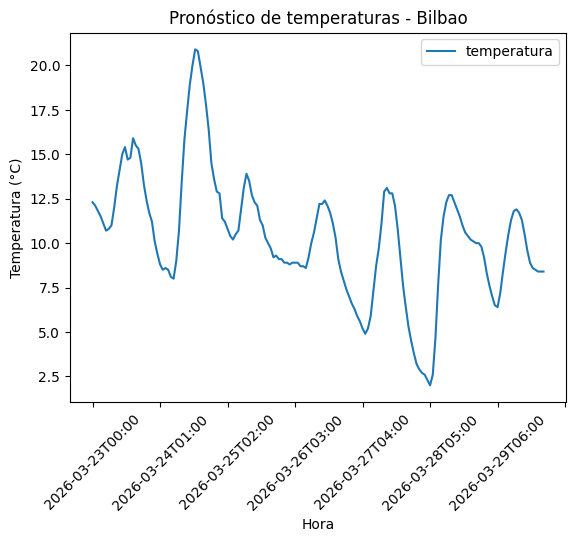

In [ ]:
temps_df.plot(x="hora", y="temperatura", title="Pronóstico de temperaturas - Bilbao")
plt.xlabel("Hora")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45);